
# 1. Data Exploration
**Dataset Source:** [UCI Machine Learning Repository - Bank Marketing](https://www.kaggle.com/datasets/captaintyping/uci-bank-marketing-dataset/data)

### Introduction
This notebook documents the data preparation and feature engineering process for the Bank Marketing dataset.
The objective is to process the data so that a Logistic Regression model can be trained to predict
whether a client will subscribe to a term deposit ('yes' or 'no').


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [12]:
df = pd.read_csv('bank-additional-full.csv', sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [13]:
(df == 'unknown').sum()

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

## 1.1 Handling Missing Values

### Identification of Implicit Missing Values
Upon exploring the dataset, I identified that there are no "explicit" missing values (NaN or nulls). However, there are significant values represented by the string `"unknown"`. These appear in several categorical features, most notably in `job`, `education`, `housing`, and `loan`.

I am opting for Imputation using the Mode (the most frequent value) for categorical variables.

**Reasoning:**
1. **Preserving Data Volume:** Simply dropping all rows containing "unknown" would result in a significant loss of data (over 10% of the dataset), which could introduce bias and reduce the statistical power of the model.
2. **Feature Nature:** Since these features are categorical, the Mode is a statistically sound measure of central tendency to fill in gaps without introducing numerical outliers.

### Ordering and Data Leakage Prevention
I am performing the Train-Test Split *before* calculating the Mode for imputation. Calculating statistics (like the most frequent category) on the entire dataset would lead to Data Leakage, as information from the test set would "leak" into the training process. By splitting first, I ensure that the "unknown" values in the test set are filled based only on the patterns found in the training data.

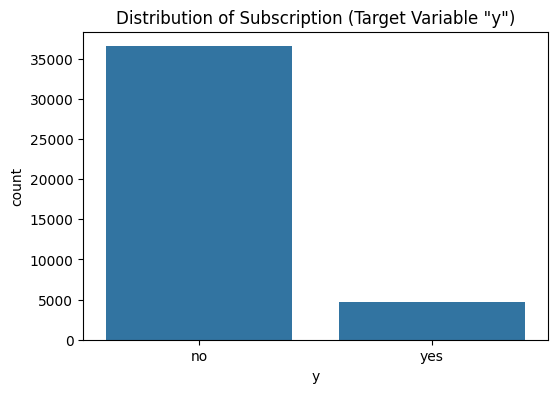

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title('Distribution of Subscription (Target Variable "y")')
plt.show()

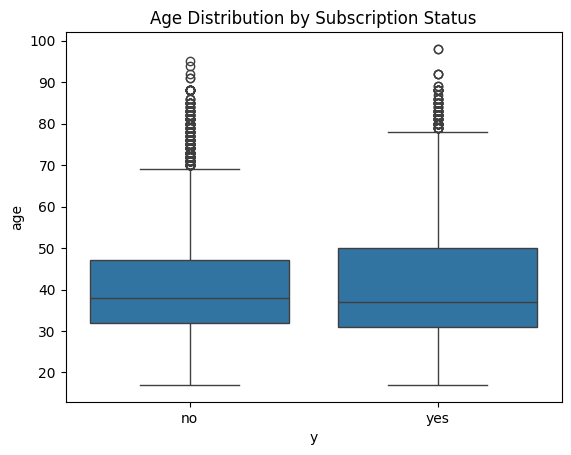

In [25]:
sns.boxplot(x='y', y='age', data = df)
plt.title('Age Distribution by Subscription Status')
plt.show()

## 1.2 Train-Test Split

### Objective
Before performing any data transformations, I am splitting the dataset into a **Training set (80%)** and a **Test set (20%)**.

If I were to calculate the "Mode" for missing values or the "Mean" for scaling using the entire dataset, information from the Test set would "leak" into the Training set. This would result in over-optimistic performance metrics that do not reflect how the model will perform on truly unseen data.

By splitting now, I ensure that all data preparation (imputation, encoding, and scaling) is learned strictly from the training data and then applied to the test data.


In [19]:
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Total rows in original data: {len(df)}")
print(f"Rows in Training set: {len(X_train)}")
print(f"Rows in Test set: {len(X_test)}")

Total rows in original data: 41188
Rows in Training set: 32950
Rows in Test set: 8238
